# Classification des radiographies pulmonaires COVID-19 — VGG16 Clahe_False Augmentation Famse

In [1]:
# =========================
# Installation (Google Colab)
# =========================

!pip -q install kagglehub opencv-python scikit-learn seaborn shap


In [2]:
# =========================
# Imports et environnement
# =========================

import os
import gc
import json
import random
from pathlib import Path

import cv2
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Compatibilité SHAP / NumPy selon les versions installées
try:
    np.bool
except AttributeError:
    np.bool = bool  # type: ignore[attr-defined]

try:
    np.int
except AttributeError:
    np.int = int  # type: ignore[attr-defined]

print("TensorFlow version :", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices("GPU"))

# Reproductibilité
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("Déterminisme TensorFlow activé.")
except Exception as e:
    print("Déterminisme non activé :", e)


2026-06-15 12:12:45.679848: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781525565.899917      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781525565.966406      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781525566.480182      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781525566.480223      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781525566.480226      58 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Déterminisme TensorFlow activé.


In [3]:
# =========================
# Configuration générale
# =========================
# Toute la configuration utile est centralisée ici.

# -------------------------
# Dossier des splits CSV
# -------------------------
# Ici, on suppose explicitement que les CSV sont bons et qu'ils se trouvent
# dans l'input Kaggle indiqué ci-dessous.
SPLITS_DIR = Path("/kaggle/input/datasets/housseinabbouchi/dataset-splits/")

TRAIN_CSV = SPLITS_DIR / "train_df.csv"
VAL_CSV   = SPLITS_DIR / "val_df.csv"
TEST_CSV  = SPLITS_DIR / "test_df.csv"

# -------------------------
# Classes / labels
# -------------------------
CATEGORIES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
NUM_CLASSES = len(CATEGORIES)

CLASS_TO_ID = {label: idx for idx, label in enumerate(CATEGORIES)}
ID_TO_CLASS = {idx: label for label, idx in CLASS_TO_ID.items()}

# -------------------------
# Prétraitement images
# -------------------------
TARGET_SIZE = 224
N_CHANNELS = 3

APPLY_MASK = True
APPLY_CLAHE = False   # À activer si tu veux tester la variante CLAHE
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# -------------------------
# Data augmentation
# -------------------------
USE_AUGMENTATION = False

AUG_ROTATION = 0.04
AUG_TRANSLATION = 0.03
AUG_ZOOM = 0.05
AUG_CONTRAST = 0.06

# -------------------------
# tf.data
# -------------------------
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DATASET = False

# -------------------------
# Entraînement
# -------------------------
TRAIN_MODEL = True
USE_CLASS_WEIGHTS = True

# Phase 1 : tête seule
INITIAL_EPOCHS = 8
HEAD_LEARNING_RATE = 1e-3

# Phase 2 : fine-tuning
DO_FINE_TUNING = True
FINE_TUNE_EPOCHS = 8
FINE_TUNE_LEARNING_RATE = 1e-5
UNFREEZE_LAST_N_LAYERS = 4  # VGG16 : on dégèle typiquement le block5

# -------------------------
# Sauvegarde
# -------------------------
SAVE_DIR = Path("/kaggle/working/saved_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH_PHASE1 = SAVE_DIR / "best_vgg16_phase1_fixed_splits.keras"
BEST_MODEL_PATH_FINAL  = SAVE_DIR / "best_vgg16_finetuned_fixed_splits.keras"
FINAL_MODEL_PATH       = SAVE_DIR / "final_vgg16_fixed_splits.keras"
HISTORY_CSV_PATH       = SAVE_DIR / "vgg16_history.csv"
REPORT_CSV_PATH        = SAVE_DIR / "vgg16_classification_report_test.csv"
RESULTS_CSV_PATH       = SAVE_DIR / "vgg16_test_predictions_detailed.csv"
CONFIG_JSON_PATH       = SAVE_DIR / "vgg16_run_config.json"
LABELS_JSON_PATH       = SAVE_DIR / "vgg16_labels_map.json"

# -------------------------
# Interprétabilité
# -------------------------
# Pour VGG, on cible de préférence une couche convolutionnelle INTERNE
# du backbone (souvent plus fine qu'une Grad-CAM calculée sur la sortie spatiale finale).
# Laisse None pour une détection automatique de la dernière couche conv compatible.
GRADCAM_BACKBONE_INTERNAL_LAYER_NAME = None

SHAP_MAX_EVALS = 100
SHAP_BATCH_SIZE = 8
SHAP_RUN_ON_ALL_SELECTED = False   # Peut être lent sur Kaggle/Colab ; passe à True si besoin


## 1. Chargement des splits figés

Dans cette version, on **fait confiance** aux fichiers CSV du dossier `dataset_splits`.
On ne multiplie plus les contrôles de chemins : la logique est volontairement plus simple.

Les CSV doivent contenir au moins :
- `label`
- `image_path`
- `mask_path`


In [4]:
# =========================
# Chargement des CSV de split
# =========================

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("train_df :", train_df.shape)
print("val_df   :", val_df.shape)
print("test_df  :", test_df.shape)

display(train_df.head())


train_df : (14815, 3)
val_df   : (3175, 3)
test_df  : (3175, 3)


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


In [5]:
# =========================
# Téléchargement / localisation du dataset Kaggle
# =========================
# Les CSV ont été générés dans un environnement Kaggle.
# Sur Colab, on télécharge le dataset puis on remappe les chemins.

import kagglehub

data_path = Path(kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database"))
print("Dataset Kaggle localisé dans :", data_path)

candidate_root = data_path / "COVID-19_Radiography_Dataset"
if candidate_root.exists():
    dataset_root = candidate_root
else:
    dataset_root = next(p for p in data_path.rglob("COVID-19_Radiography_Dataset") if p.is_dir())

print("dataset_root =", dataset_root)


Dataset Kaggle localisé dans : /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database
dataset_root = /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset


In [6]:
# =========================
# Remapping des chemins CSV -> chemins locaux Colab
# =========================
# Hypothèse choisie ici :
# - les CSV sont corrects ;
# - ils pointent vers des chemins de type :
#   /kaggle/input/.../COVID-19_Radiography_Dataset/<classe>/<images|masks>/<fichier>
#
# On reconstruit donc simplement le suffixe après
# "COVID-19_Radiography_Dataset/" et on le recolle à dataset_root.

def remap_csv_path_to_local(csv_path: str, dataset_root: Path):
    csv_path = str(csv_path)
    marker = "COVID-19_Radiography_Dataset/"
    suffix = csv_path.split(marker, 1)[1]
    return str(dataset_root / suffix)

def prepare_split_df(df):
    out = df.copy()
    out["image_path_local"] = out["image_path"].apply(lambda p: remap_csv_path_to_local(p, dataset_root))
    out["mask_path_local"] = out["mask_path"].apply(lambda p: remap_csv_path_to_local(p, dataset_root))
    out["label_id"] = out["label"].map(CLASS_TO_ID).astype(np.int32)
    return out

train_df = prepare_split_df(train_df)
val_df   = prepare_split_df(val_df)
test_df  = prepare_split_df(test_df)

display(train_df.head())


,label,image_path,mask_path,image_path_local,mask_path_local,label_id
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,2
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,3
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,1
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0


In [7]:
# =========================
# Sauvegarde de la configuration de run
# =========================

run_config = {
    "seed": SEED,
    "categories": CATEGORIES,
    "target_size": TARGET_SIZE,
    "n_channels": N_CHANNELS,
    "apply_mask": APPLY_MASK,
    "apply_clahe": APPLY_CLAHE,
    "use_augmentation": USE_AUGMENTATION,
    "batch_size": BATCH_SIZE,
    "train_model": TRAIN_MODEL,
    "initial_epochs": INITIAL_EPOCHS,
    "head_learning_rate": HEAD_LEARNING_RATE,
    "do_fine_tuning": DO_FINE_TUNING,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "fine_tune_learning_rate": FINE_TUNE_LEARNING_RATE,
    "unfreeze_last_n_layers": UNFREEZE_LAST_N_LAYERS,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "splits_dir": str(SPLITS_DIR),
    "dataset_root": str(dataset_root),
}

with open(CONFIG_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2, ensure_ascii=False)

with open(LABELS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump({"class_to_id": CLASS_TO_ID, "id_to_class": ID_TO_CLASS}, f, indent=2, ensure_ascii=False)

print("Configuration sauvegardée dans :", CONFIG_JSON_PATH)
print("Mapping des labels sauvegardé dans :", LABELS_JSON_PATH)


Configuration sauvegardée dans : /kaggle/working/saved_models/vgg16_run_config.json
Mapping des labels sauvegardé dans : /kaggle/working/saved_models/vgg16_labels_map.json


,split,class_name,count
0,train,COVID,2531
1,train,Normal,7134
2,train,Lung_Opacity,4208
3,train,Viral Pneumonia,942
4,validation,COVID,543
5,validation,Normal,1529
6,validation,Lung_Opacity,902
7,validation,Viral Pneumonia,201
8,test,COVID,542
9,test,Normal,1529


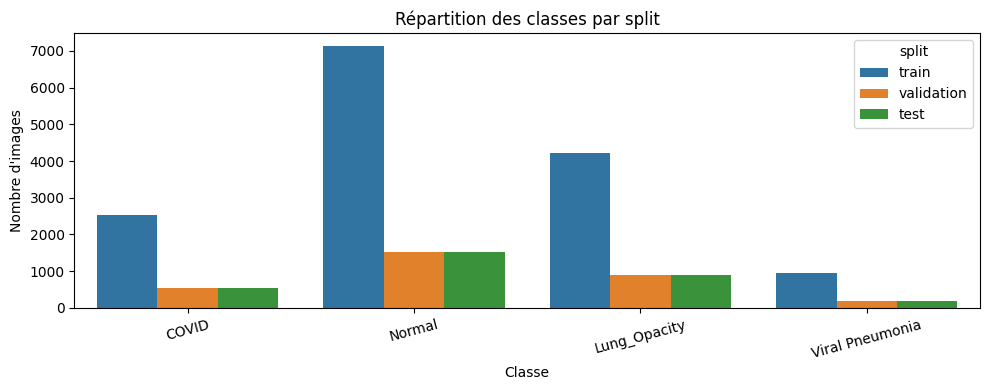

In [9]:
# =========================
# Répartition des classes par split
# =========================

def make_split_distribution(df, split_name):
    counts = df["label"].value_counts().reindex(CATEGORIES)
    return pd.DataFrame({
        "split": split_name,
        "class_name": CATEGORIES,
        "count": counts.values
    })

split_dist_df = pd.concat([
    make_split_distribution(train_df, "train"),
    make_split_distribution(val_df, "validation"),
    make_split_distribution(test_df, "test"),
], ignore_index=True)

display(split_dist_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=split_dist_df, x="class_name", y="count", hue="split")
plt.title("Répartition des classes par split")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


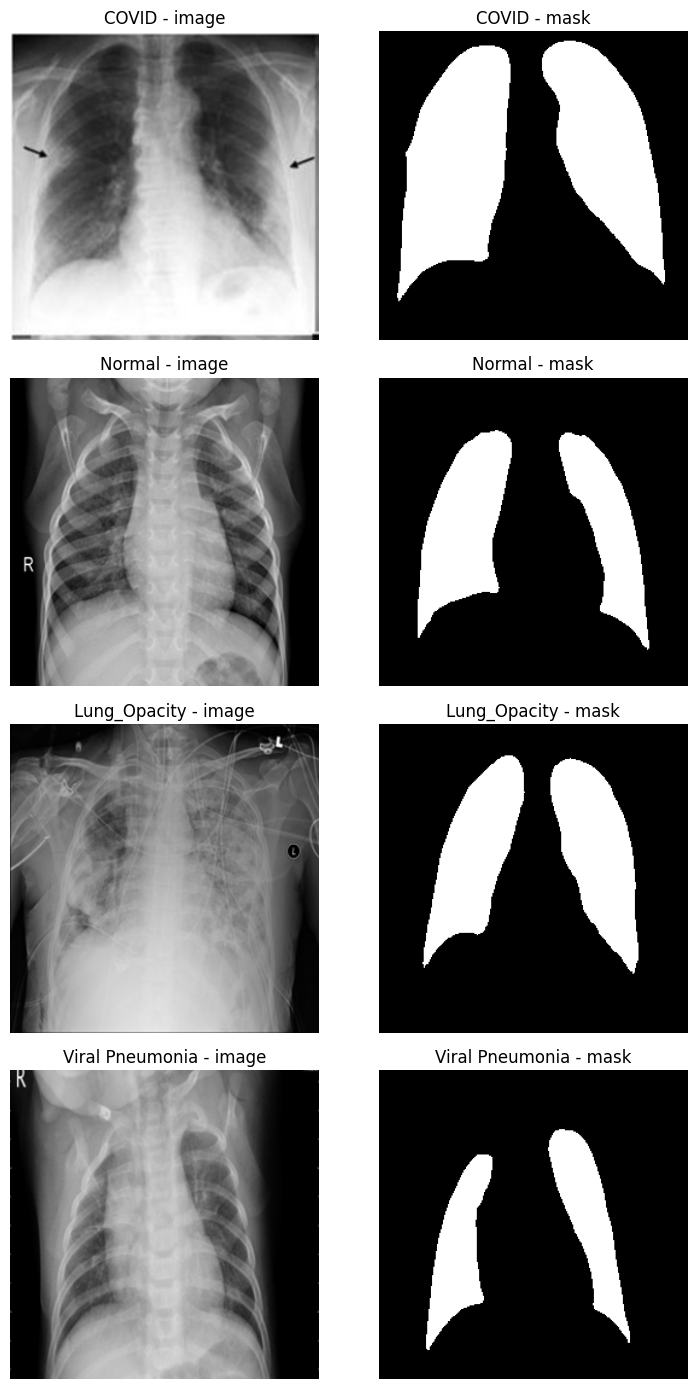

In [10]:
# =========================
# Vérification visuelle rapide
# =========================

fig, axes = plt.subplots(4, 2, figsize=(8, 14))

for i, category in enumerate(CATEGORIES):
    row = train_df[train_df["label"] == category].iloc[0]

    img = cv2.imread(row["image_path_local"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row["mask_path_local"], cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"{category} - image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"{category} - mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


## 2. Prétraitement `on-the-fly` pour VGG16

Ici, on garde l'esprit des notebooks précédents mais on adapte le format d'entrée au transfert learning :

- lecture en **grayscale**
- application du **masque** si activée
- **resize en 224x224**
- **CLAHE optionnel**
- conversion vers **RGB 3 canaux**
- appel à `preprocess_input` juste avant la base VGG16

Important : l'image retournée par la fonction de prétraitement reste sur une échelle compatible avec `preprocess_input`.


In [11]:
# =========================
# Fonctions de prétraitement
# =========================

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_TILE_SIZE
)

def preprocess_image_for_vgg16_numpy(image_path, mask_path):
    '''
    Prétraitement côté Python / OpenCV pour VGG16.

    Sortie :
    - image float32 de forme (TARGET_SIZE, TARGET_SIZE, 3)
    - pixels gardés sur une échelle [0, 255]
      pour rester compatibles avec preprocess_input
    '''
    if hasattr(image_path, "numpy"):
        image_path = image_path.numpy()
    if hasattr(mask_path, "numpy"):
        mask_path = mask_path.numpy()

    image_path = image_path.decode("utf-8") if isinstance(image_path, (bytes, np.bytes_)) else str(image_path)
    mask_path = mask_path.decode("utf-8") if isinstance(mask_path, (bytes, np.bytes_)) else str(mask_path)

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")

    if APPLY_MASK:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Impossible de lire le masque : {mask_path}")

        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)
        img = img * mask

    img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)

    if APPLY_CLAHE:
        img = clahe.apply(img)

    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = img.astype(np.float32)
    return img


def tf_preprocess_image(image_path, mask_path, label):
    image = tf.numpy_function(
        func=preprocess_image_for_vgg16_numpy,
        inp=[image_path, mask_path],
        Tout=tf.float32
    )

    image.set_shape((TARGET_SIZE, TARGET_SIZE, N_CHANNELS))
    label = tf.cast(label, tf.int32)
    return image, label


def build_augmentation_layer():
    aug_layers = []

    if AUG_ROTATION > 0:
        aug_layers.append(layers.RandomRotation(AUG_ROTATION, seed=SEED))
    if AUG_TRANSLATION > 0:
        aug_layers.append(layers.RandomTranslation(AUG_TRANSLATION, AUG_TRANSLATION, seed=SEED))
    if AUG_ZOOM > 0:
        aug_layers.append(layers.RandomZoom(AUG_ZOOM, seed=SEED))
    if AUG_CONTRAST > 0:
        aug_layers.append(layers.RandomContrast(AUG_CONTRAST, seed=SEED))

    if len(aug_layers) == 0:
        return keras.Sequential(name="empty_augmentation")

    return keras.Sequential(aug_layers, name="data_augmentation")


def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path_local"].values,
        df["mask_path_local"].values,
        df["label_id"].values
    ))

    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(tf_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)

    if CACHE_DATASET:
        ds = ds.cache()

    ds = ds.prefetch(AUTOTUNE)
    return ds


In [12]:
# =========================
# Class weights
# =========================

classes = np.array(sorted(train_df["label_id"].unique()))
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"].values
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights_values)}
print("Class weights :", class_weight_dict)


Class weights : {0: 1.4633544053733702, 1: 0.5191687692738997, 2: 0.8801687262357415, 3: 3.9317940552016983}


In [13]:
# =========================
# Pipelines tf.data
# =========================

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

for batch_images, batch_labels in train_ds.take(1):
    print("Shape images batch :", batch_images.shape)
    print("Shape labels batch :", batch_labels.shape)


I0000 00:00:1781525679.272368      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781525679.278499      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Shape images batch : (16, 224, 224, 3)
Shape labels batch : (16,)


In [14]:
# =========================
# Bloc de data augmentation (optionnel)
# =========================

def build_augmentation_layer():
    return keras.Sequential(
        [
            layers.RandomRotation(AUG_ROTATION, seed=SEED),
            layers.RandomTranslation(AUG_TRANSLATION, AUG_TRANSLATION, seed=SEED),
            layers.RandomZoom(AUG_ZOOM, seed=SEED),
            layers.RandomContrast(AUG_CONTRAST, seed=SEED),
        ],
        name="data_augmentation"
    )


## 3. Architecture du modèle de transfert learning

La structure retenue est :

- entrée image `224x224x3`
- data augmentation optionnelle
- `preprocess_input`
- base **VGG16** pré-entraînée ImageNet
- `GlobalAveragePooling2D`
- petite tête dense
- softmax 4 classes


In [15]:
# =========================
# Construction du modèle VGG16
# =========================

def build_vgg16_transfer_model(input_shape=(TARGET_SIZE, TARGET_SIZE, N_CHANNELS), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name="input_image")

    x = inputs

    if USE_AUGMENTATION:
        x = build_augmentation_layer()(x)

    # Le preprocess_input de VGG16 attend des images RGB sur l'échelle [0, 255].
    x = layers.Lambda(preprocess_input, name="vgg16_preprocess")(x)

    backbone = VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(0.30, name="head_dropout")(x)
    x = layers.Dense(256, activation="relu", name="dense_256")(x)
    x = layers.Dropout(0.20, name="head_dropout_2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="vgg16_transfer_learning")
    return model

model = build_vgg16_transfer_model()
model.summary()

def find_backbone_layer_name(model):
    # On cherche le sous-modèle VGG16 inséré comme couche du modèle global.
    for layer in model.layers:
        if isinstance(layer, keras.Model) and "vgg" in layer.name.lower():
            return layer.name
    raise ValueError("Impossible de trouver la couche backbone VGG16 dans le modèle.")

BACKBONE_LAYER_NAME = find_backbone_layer_name(model)
print("Backbone détecté :", BACKBONE_LAYER_NAME)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preprocess (Lambda)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Backbone détecté : vgg16


In [16]:
# =========================
# Compilation - phase 1 (tête seule)
# =========================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=HEAD_LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [17]:
# =========================
# Callbacks
# =========================

callbacks_phase1 = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH_PHASE1),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]


In [18]:
# =========================
# Entraînement - phase 1
# =========================

history_phase1 = None

if TRAIN_MODEL:
    fit_kwargs = dict(
        x=train_ds,
        validation_data=val_ds,
        epochs=INITIAL_EPOCHS,
        callbacks=callbacks_phase1,
        verbose=1
    )

    if USE_CLASS_WEIGHTS:
        fit_kwargs["class_weight"] = class_weight_dict

    history_phase1 = model.fit(**fit_kwargs)
else:
    print("TRAIN_MODEL = False -> phase 1 non lancée.")


Epoch 1/8


I0000 00:00:1781525687.403044     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


926/926 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.5766 - loss: 1.3519
Epoch 1: val_loss improved from None to 0.66608, saving model to /kaggle/working/saved_models/best_vgg16_phase1_fixed_splits.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/best_vgg16_phase1_fixed_splits.keras
926/926 ━━━━━━━━━━━━━━━━━━━━ 374s 398ms/step - accuracy: 0.6409 - loss: 0.9141 - val_accuracy: 0.7411 - val_loss: 0.6661 - learning_rate: 0.0010
Epoch 2/8
926/926 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7008 - loss: 0.6537
Epoch 2: val_loss improved from 0.66608 to 0.58823, saving model to /kaggle/working/saved_models/best_vgg16_phase1_fixed_splits.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/best_vgg16_phase1_fixed_splits.keras
926/926 ━━━━━━━━━━━━━━━━━━━━ 167s 180ms/step - accuracy: 0.7052 - loss: 0.6397 - val_accuracy: 0.7631 - val_loss: 0.5882 - learning_rate: 0.0010
Epoch 3/8
926/926 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7236 - loss:

In [19]:
# =========================
# Fine-tuning (phase 2)
# =========================
# On dégèle seulement les dernières couches du backbone.
# Pour VGG16, cela correspond typiquement au block5.
# Le code garde une logique générique : si des BatchNormalization existent, on les laisse gelées.

history_phase2 = None

if TRAIN_MODEL and DO_FINE_TUNING:
    backbone = model.get_layer(BACKBONE_LAYER_NAME)
    backbone.trainable = True

    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    if UNFREEZE_LAST_N_LAYERS is not None and UNFREEZE_LAST_N_LAYERS > 0:
        trainable_names = set(layer.name for layer in backbone.layers[-UNFREEZE_LAST_N_LAYERS:])

        for layer in backbone.layers:
            if layer.name not in trainable_names and not isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks_phase2 = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=str(BEST_MODEL_PATH_FINAL),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    fit_kwargs = dict(
        x=train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks_phase2,
        verbose=1
    )

    if USE_CLASS_WEIGHTS:
        fit_kwargs["class_weight"] = class_weight_dict

    history_phase2 = model.fit(**fit_kwargs)
else:
    if not TRAIN_MODEL:
        print("TRAIN_MODEL = False -> fine-tuning non lancé.")
    else:
        print("DO_FINE_TUNING = False -> fine-tuning désactivé.")


Epoch 1/8
926/926 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7829 - loss: 0.4795
Epoch 1: val_loss improved from None to 0.44393, saving model to /kaggle/working/saved_models/best_vgg16_finetuned_fixed_splits.keras

Epoch 1: finished saving model to /kaggle/working/saved_models/best_vgg16_finetuned_fixed_splits.keras
926/926 ━━━━━━━━━━━━━━━━━━━━ 190s 203ms/step - accuracy: 0.7983 - loss: 0.4494 - val_accuracy: 0.8217 - val_loss: 0.4439 - learning_rate: 1.0000e-05
Epoch 2/8
926/926 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8368 - loss: 0.3598
Epoch 2: val_loss improved from 0.44393 to 0.38486, saving model to /kaggle/working/saved_models/best_vgg16_finetuned_fixed_splits.keras

Epoch 2: finished saving model to /kaggle/working/saved_models/best_vgg16_finetuned_fixed_splits.keras
926/926 ━━━━━━━━━━━━━━━━━━━━ 177s 191ms/step - accuracy: 0.8404 - loss: 0.3575 - val_accuracy: 0.8523 - val_loss: 0.3849 - learning_rate: 1.0000e-05
Epoch 3/8
926/926 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/s

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.640904,0.914150,0.741102,0.666076,0.001
1,0.705231,0.639747,0.763150,0.588230,0.001
2,0.727438,0.591628,0.759370,0.591257,0.001
3,0.743098,0.562943,0.765039,0.565657,0.001
4,0.745393,0.546620,0.798110,0.501001,0.001


Historique sauvegardé dans : /kaggle/working/saved_models/vgg16_history.csv


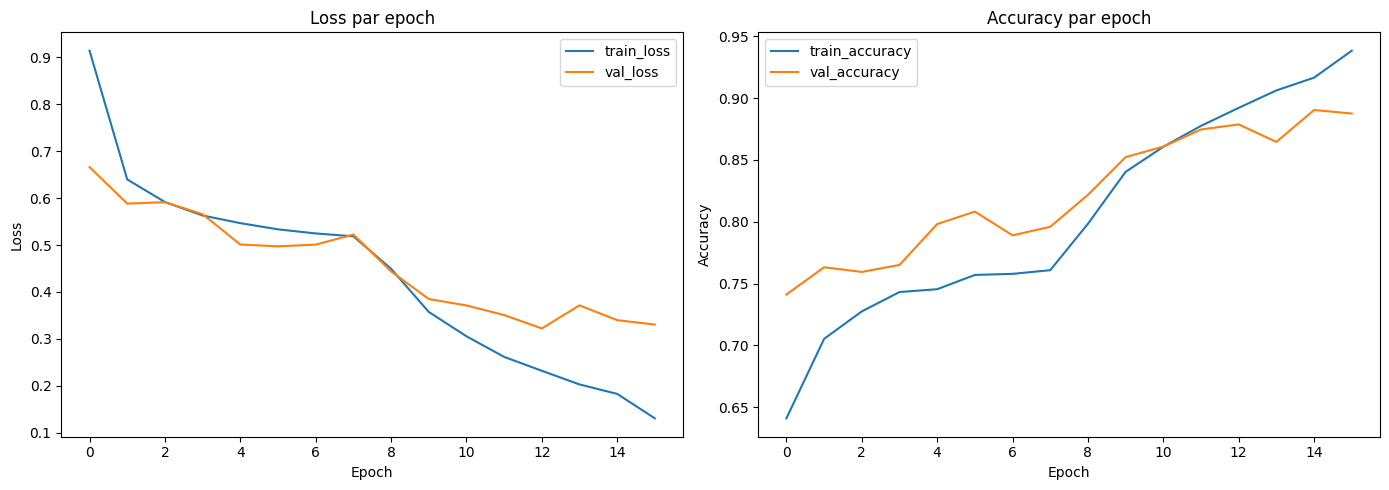

Modèle final sauvegardé dans : /kaggle/working/saved_models/final_vgg16_fixed_splits.keras


In [20]:
# =========================
# Fusion des historiques, sauvegarde du modèle et courbes d'apprentissage
# =========================

def combine_histories(history1, history2=None):
    if history1 is None:
        return {}

    combined = {}
    for key, values in history1.history.items():
        combined[key] = list(values)

    if history2 is not None:
        for key, values in history2.history.items():
            combined[key] = combined.get(key, []) + list(values)

    return combined

full_history = combine_histories(history_phase1, history_phase2)

if len(full_history) > 0:
    history_df = pd.DataFrame(full_history)
    display(history_df.head())
    history_df.to_csv(HISTORY_CSV_PATH, index=False)
    print("Historique sauvegardé dans :", HISTORY_CSV_PATH)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(full_history["loss"], label="train_loss")
    axes[0].plot(full_history["val_loss"], label="val_loss")
    axes[0].set_title("Loss par epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(full_history["accuracy"], label="train_accuracy")
    axes[1].plot(full_history["val_accuracy"], label="val_accuracy")
    axes[1].set_title("Accuracy par epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Sauvegarde du modèle final pour réutilisation ultérieure
model.save(FINAL_MODEL_PATH)
print("Modèle final sauvegardé dans :", FINAL_MODEL_PATH)


## 4. Évaluation sur le test set

Comme dans les notebooks précédents, on calcule :
- la loss et l'accuracy globales ;
- le `classification_report` ;
- la matrice de confusion ;
- un tableau détaillé par classe.

En plus, on enregistre un **fichier détaillé de prédictions** qui servira à la sélection des exemples pour Grad-CAM et SHAP.


In [21]:
# =========================
# Évaluation sur le jeu de test
# =========================

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

y_proba = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)
y_test = test_df["label_id"].values

report = classification_report(
    y_test,
    y_pred,
    target_names=CATEGORIES,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

report_df.to_csv(REPORT_CSV_PATH, index=True)
print("Classification report sauvegardé dans :", REPORT_CSV_PATH)

test_results_df = test_df.copy()
test_results_df["y_true"] = y_test
test_results_df["y_pred"] = y_pred
test_results_df["true_name"] = test_results_df["y_true"].map(ID_TO_CLASS)
test_results_df["pred_name"] = test_results_df["y_pred"].map(ID_TO_CLASS)
test_results_df["is_correct"] = test_results_df["y_true"] == test_results_df["y_pred"]
test_results_df["pred_confidence"] = y_proba.max(axis=1)

for class_id, class_name in ID_TO_CLASS.items():
    test_results_df[f"proba_{class_name}"] = y_proba[:, class_id]

display(test_results_df.head())

test_results_df.to_csv(RESULTS_CSV_PATH, index=False)
print("Prédictions détaillées sauvegardées dans :", RESULTS_CSV_PATH)


199/199 ━━━━━━━━━━━━━━━━━━━━ 81s 409ms/step - accuracy: 0.8863 - loss: 0.3110
Test loss     : 0.3110
Test accuracy : 0.8863
199/199 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step


,precision,recall,f1-score,support
COVID,0.819030,0.809963,0.814471,542.000000
Normal,0.884918,0.955526,0.918868,1529.000000
Lung_Opacity,0.921618,0.808204,0.861193,902.000000
Viral Pneumonia,0.939086,0.915842,0.927318,202.000000
accuracy,0.886299,0.886299,0.886299,0.886299
macro avg,0.891163,0.872384,0.880463,3175.000000
weighted avg,0.887543,0.886299,0.885199,3175.000000


Classification report sauvegardé dans : /kaggle/working/saved_models/vgg16_classification_report_test.csv


,label,image_path,mask_path,image_path_local,mask_path_local,label_id,y_true,y_pred,true_name,pred_name,is_correct,pred_confidence,proba_COVID,proba_Normal,proba_Lung_Opacity,proba_Viral Pneumonia
0,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,1,1,1,Normal,Normal,True,0.983563,0.007736,0.983563,0.008701,1.387121e-07
1,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0,0,0,COVID,COVID,True,0.948608,0.948608,0.000037,0.051355,8.325003e-09
2,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0,0,1,COVID,Normal,False,0.656680,0.311383,0.656680,0.031936,8.810686e-07
3,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,3,3,3,Viral Pneumonia,Viral Pneumonia,True,0.491084,0.008406,0.465233,0.035277,4.910842e-01
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/datasets/tawsifurrahman/covid19-...,/kaggle/input/datasets/tawsifurrahman/covid19-...,0,0,0,COVID,COVID,True,0.997441,0.997441,0.000003,0.002556,1.375609e-07


Prédictions détaillées sauvegardées dans : /kaggle/working/saved_models/vgg16_test_predictions_detailed.csv


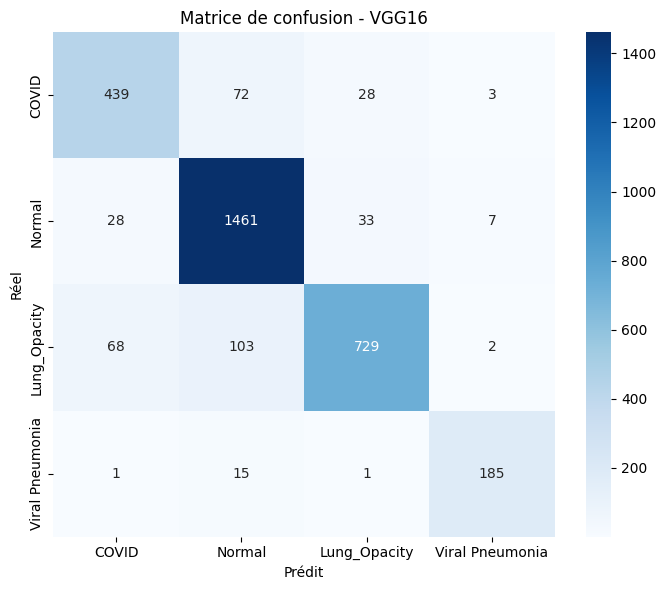

In [22]:
# =========================
# Matrice de confusion
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES
)
plt.title("Matrice de confusion - VGG16")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()


In [23]:
# =========================
# Tableau de métriques par classe
# =========================

per_class_df = report_df.loc[CATEGORIES, ["precision", "recall", "f1-score", "support"]].copy()
per_class_df = per_class_df.reset_index().rename(columns={"index": "class_name"})
display(per_class_df)


,class_name,precision,recall,f1-score,support
0,COVID,0.819030,0.809963,0.814471,542.0
1,Normal,0.884918,0.955526,0.918868,1529.0
2,Lung_Opacity,0.921618,0.808204,0.861193,902.0
3,Viral Pneumonia,0.939086,0.915842,0.927318,202.0


## 5. Sélection d'exemples pour l'interprétabilité

On sélectionne, dans le **test set** :

- un exemple **bien classé** par catégorie ;
- un exemple **mal classé** par catégorie ;

quand ces exemples existent.

Cette stratégie permet de comparer :
- ce que le modèle regarde quand il réussit ;
- ce qu'il regarde quand il se trompe.


In [24]:
# =========================
# Sélection d'exemples corrects / incorrects par catégorie
# =========================

def select_examples_for_interpretability(results_df, categories):
    '''
    Pour chaque vraie classe :
    - on prend un exemple correct (si disponible)
    - on prend un exemple incorrect (si disponible)

    Le tri par confiance rend les cas plus parlants :
    - cas correct : on prend un exemple bien reconnu
    - cas incorrect : on prend une erreur "sûre" du modèle
    '''
    selected_rows = []

    for category in categories:
        class_id = CLASS_TO_ID[category]
        subset = results_df[results_df["y_true"] == class_id].copy()

        correct_subset = subset[subset["is_correct"]].sort_values("pred_confidence", ascending=False)
        wrong_subset   = subset[~subset["is_correct"]].sort_values("pred_confidence", ascending=False)

        if len(correct_subset) > 0:
            row = correct_subset.iloc[0].copy()
            row["example_type"] = "correct"
            selected_rows.append(row)

        if len(wrong_subset) > 0:
            row = wrong_subset.iloc[0].copy()
            row["example_type"] = "incorrect"
            selected_rows.append(row)

    if len(selected_rows) == 0:
        return pd.DataFrame()

    return pd.DataFrame(selected_rows).reset_index(drop=True)

examples_df = select_examples_for_interpretability(test_results_df, CATEGORIES)
display(examples_df[["label", "example_type", "true_name", "pred_name", "pred_confidence"]])


,label,example_type,true_name,pred_name,pred_confidence
0,COVID,correct,COVID,COVID,1.000000
1,COVID,incorrect,COVID,Normal,0.990631
2,Normal,correct,Normal,Normal,1.000000
3,Normal,incorrect,Normal,Lung_Opacity,0.996004
4,Lung_Opacity,correct,Lung_Opacity,Lung_Opacity,1.000000
5,Lung_Opacity,incorrect,Lung_Opacity,Normal,0.996540
6,Viral Pneumonia,correct,Viral Pneumonia,Viral Pneumonia,1.000000
7,Viral Pneumonia,incorrect,Viral Pneumonia,Normal,0.998045


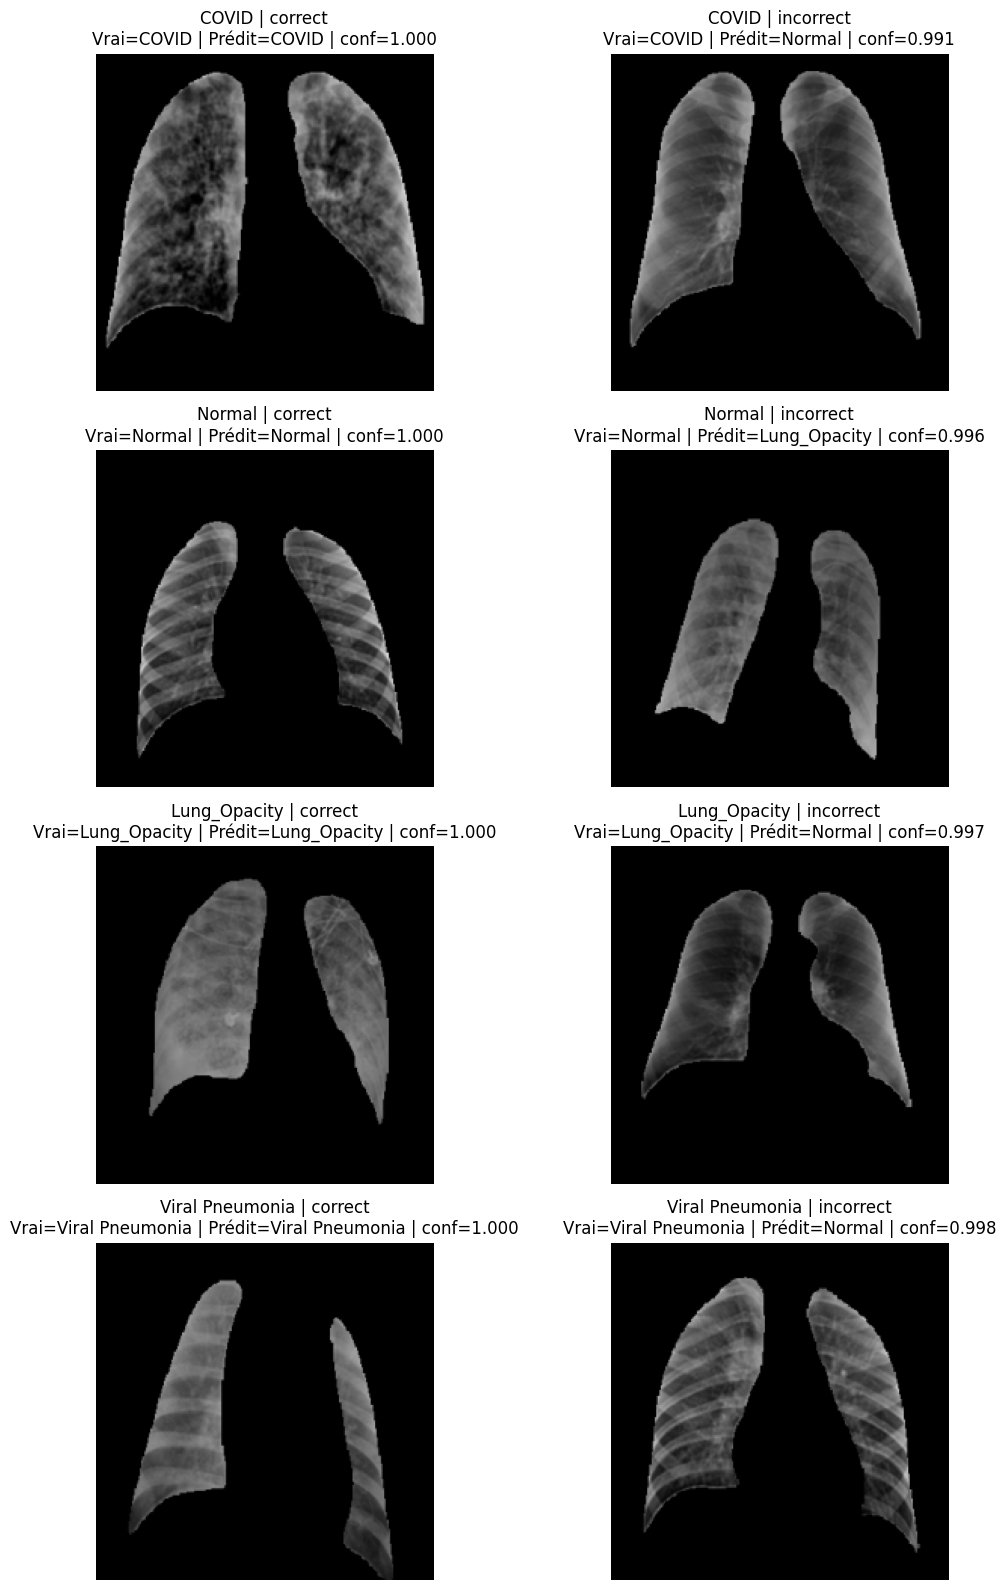

In [25]:
# =========================
# Visualisation des exemples sélectionnés
# =========================

def load_preprocessed_image_from_row(row):
    '''
    Recharge UNE image via exactement le même prétraitement que celui utilisé
    pendant l'entraînement / l'évaluation.
    '''
    image = preprocess_image_for_vgg16_numpy(
        row["image_path_local"].encode("utf-8"),
        row["mask_path_local"].encode("utf-8")
    )
    return image

def show_selected_examples(examples_df):
    if len(examples_df) == 0:
        print("Aucun exemple disponible.")
        return

    n = len(examples_df)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(12, 4 * rows))

    for i, (_, row) in enumerate(examples_df.iterrows()):
        img = load_preprocessed_image_from_row(row)

        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow((img / 255.0).clip(0, 1))
        plt.axis("off")
        plt.title(
            f"{row['true_name']} | {row['example_type']}\n"
            f"Vrai={row['true_name']} | Prédit={row['pred_name']} | conf={row['pred_confidence']:.3f}"
        )

    plt.tight_layout()
    plt.show()

show_selected_examples(examples_df)


## 6. Grad-CAM

Pour VGG16, on utilise ici une **couche convolutionnelle interne du backbone** comme cible Grad-CAM.

Pourquoi ce choix :
- les cartes sont souvent **plus fines** et **plus lisibles** ;
- on reste dans une logique plus proche de Grad-CAM "classique" ;
- cela permet d'inspecter ce que voit vraiment le backbone juste avant la tête de classification.

Par défaut, le notebook cherche automatiquement la **dernière couche convolutionnelle compatible** à l'intérieur de VGG16.  
Tu peux aussi forcer une couche précise via `GRADCAM_BACKBONE_INTERNAL_LAYER_NAME`.

Pour les cas **corrects**, on visualise la carte Grad-CAM de la **classe prédite**.

Pour les cas **incorrects**, on visualise :
- la carte Grad-CAM de la **classe prédite** ;
- et la carte Grad-CAM de la **vraie classe**.

Cela permet de comparer ce que le réseau a réellement activé pour l'erreur.


In [26]:

# =========================
# Outils Grad-CAM
# =========================
# Cette version cible une couche convolutionnelle INTERNE du backbone VGG16 (souvent block5_conv3 par défaut si elle est disponible).
# L'approche est plus robuste sur Kaggle/Keras 3 que de mélanger directement des tenseurs
# internes du sous-modèle backbone avec les tenseurs du modèle global.
#
# Stratégie :
# 1) on applique les couches avant le backbone (augmentation éventuelle + preprocess_input),
# 2) on entre dans le backbone VGG,
# 3) on récupère :
#    - les activations d'une couche convolutionnelle interne cible,
#    - la sortie finale spatiale du backbone,
# 4) on applique ensuite la tête de classification du modèle global.
#
# Ainsi, tout le calcul reste cohérent sous GradientTape, sans casser le graphe Keras.

def get_backbone_and_head_layers(model, backbone_name):
    """
    Retourne :
    - les couches avant le backbone,
    - le backbone,
    - les couches après le backbone.
    """
    layers_list = model.layers
    backbone_idx = None

    for i, layer in enumerate(layers_list):
        if layer.name == backbone_name:
            backbone_idx = i
            break

    if backbone_idx is None:
        raise ValueError(f"Backbone '{backbone_name}' introuvable dans le modèle.")

    pre_backbone_layers = layers_list[1:backbone_idx]   # on saute InputLayer
    backbone_layer = layers_list[backbone_idx]
    post_backbone_layers = layers_list[backbone_idx + 1:]

    return pre_backbone_layers, backbone_layer, post_backbone_layers


def find_last_conv_like_layer_in_backbone(backbone):
    """
    Cherche la dernière couche convolutionnelle exploitable dans le backbone.
    On accepte Conv2D, DepthwiseConv2D et SeparableConv2D.
    """
    conv_like_types = (
        keras.layers.Conv2D,
        keras.layers.DepthwiseConv2D,
        keras.layers.SeparableConv2D,
    )

    for layer in reversed(backbone.layers):
        try:
            output_shape = layer.output.shape
        except Exception:
            output_shape = None

        is_conv_like = isinstance(layer, conv_like_types)
        is_spatial = (output_shape is not None and len(output_shape) == 4)

        if is_conv_like and is_spatial:
            return layer.name

    raise ValueError("Aucune couche convolutionnelle interne compatible n'a été trouvée dans le backbone.")


def get_gradcam_target_layer_name(model):
    backbone_name = find_backbone_layer_name(model)
    backbone = model.get_layer(backbone_name)

    if GRADCAM_BACKBONE_INTERNAL_LAYER_NAME is not None:
        try:
            _ = backbone.get_layer(GRADCAM_BACKBONE_INTERNAL_LAYER_NAME)
        except Exception as e:
            raise ValueError(
                f"La couche '{GRADCAM_BACKBONE_INTERNAL_LAYER_NAME}' n'existe pas dans le backbone '{backbone_name}'."
            ) from e
        return GRADCAM_BACKBONE_INTERNAL_LAYER_NAME

    return find_last_conv_like_layer_in_backbone(backbone)


gradcam_backbone_name = find_backbone_layer_name(model)
gradcam_layer_name = get_gradcam_target_layer_name(model)

print("Backbone utilisé pour Grad-CAM :", gradcam_backbone_name)
print("Couche interne utilisée pour Grad-CAM :", gradcam_layer_name)


def build_backbone_grad_model(backbone, target_layer_name):
    """
    Sous-modèle interne au backbone :
    backbone.input -> [activations de la couche cible, sortie finale du backbone]
    """
    target_layer = backbone.get_layer(target_layer_name)
    return keras.Model(
        inputs=backbone.input,
        outputs=[target_layer.output, backbone.output],
        name=f"{backbone.name}_gradcam_submodel"
    )


def forward_to_target_and_predictions(image_tensor, model, backbone_name, target_layer_name):
    """
    Fait une passe avant explicite :
    input -> couches avant backbone -> sous-modèle backbone Grad-CAM -> tête

    Renvoie :
    - target_activations : activations spatiales de la couche interne cible
    - predictions       : sortie softmax finale
    """
    pre_layers, backbone_layer, post_layers = get_backbone_and_head_layers(model, backbone_name)

    x = tf.cast(image_tensor, tf.float32)

    # Couches avant backbone (augmentation éventuelle + preprocess_input)
    for layer in pre_layers:
        if isinstance(layer, (keras.layers.Dropout, keras.layers.BatchNormalization)):
            x = layer(x, training=False)
        else:
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)

    # Backbone : on récupère la couche interne cible + la sortie finale spatiale
    backbone_grad_model = build_backbone_grad_model(backbone_layer, target_layer_name)
    target_activations, backbone_output = backbone_grad_model(x, training=False)

    # Tête de classification
    x = backbone_output
    for layer in post_layers:
        if isinstance(layer, (keras.layers.Dropout, keras.layers.BatchNormalization)):
            x = layer(x, training=False)
        else:
            try:
                x = layer(x, training=False)
            except TypeError:
                x = layer(x)

    predictions = x
    return target_activations, predictions


def make_gradcam_heatmap(image_tensor, model, backbone_name, target_layer_name, class_index=None):
    """
    Calcule la heatmap Grad-CAM pour une image donnée.

    image_tensor : tenseur ou array de shape (1, H, W, C)
    class_index  : classe cible. Si None, on prend la classe prédite.
    """
    image_tensor = tf.convert_to_tensor(image_tensor, dtype=tf.float32)

    with tf.GradientTape() as tape:
        target_activations, predictions = forward_to_target_and_predictions(
            image_tensor=image_tensor,
            model=model,
            backbone_name=backbone_name,
            target_layer_name=target_layer_name
        )

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        loss = predictions[:, class_index]

    grads = tape.gradient(loss, target_activations)

    if grads is None:
        raise ValueError(
            "Grad-CAM a renvoyé des gradients nuls. "
            "Vérifie que la couche interne sélectionnée est bien connectée à la sortie du modèle."
        )

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    target_activations = target_activations[0]   # (H, W, C)
    heatmap = tf.reduce_sum(target_activations * pooled_grads, axis=-1)

    # ReLU Grad-CAM classique
    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if float(max_val) > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()


def overlay_gradcam_on_image(image_np, heatmap, alpha=0.45):
    """
    Superpose la heatmap à l'image d'origine.
    image_np est supposée être déjà au format uint8-like [0,255].
    """
    heatmap_resized = cv2.resize(heatmap, (image_np.shape[1], image_np.shape[0]))
    heatmap_uint8 = np.uint8(np.clip(255 * heatmap_resized, 0, 255))
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    image_uint8 = np.clip(image_np, 0, 255).astype(np.uint8)
    overlay = cv2.addWeighted(image_uint8, 1 - alpha, heatmap_color, alpha, 0)

    return overlay


Backbone utilisé pour Grad-CAM : vgg16
Couche interne utilisée pour Grad-CAM : block5_conv3


##########################################################################################
Grad-CAM — catégorie : COVID
##########################################################################################


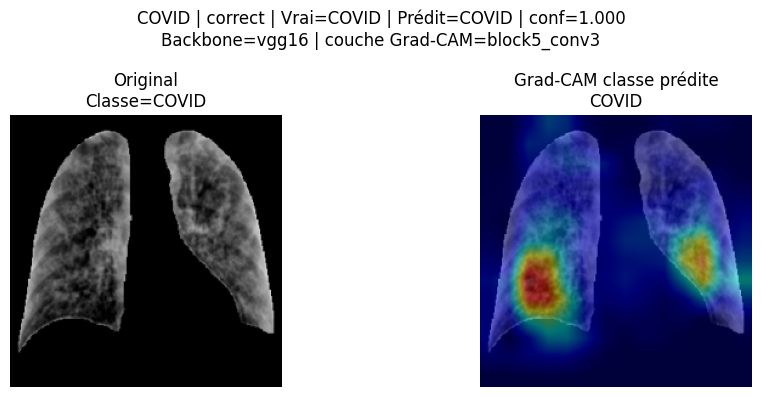

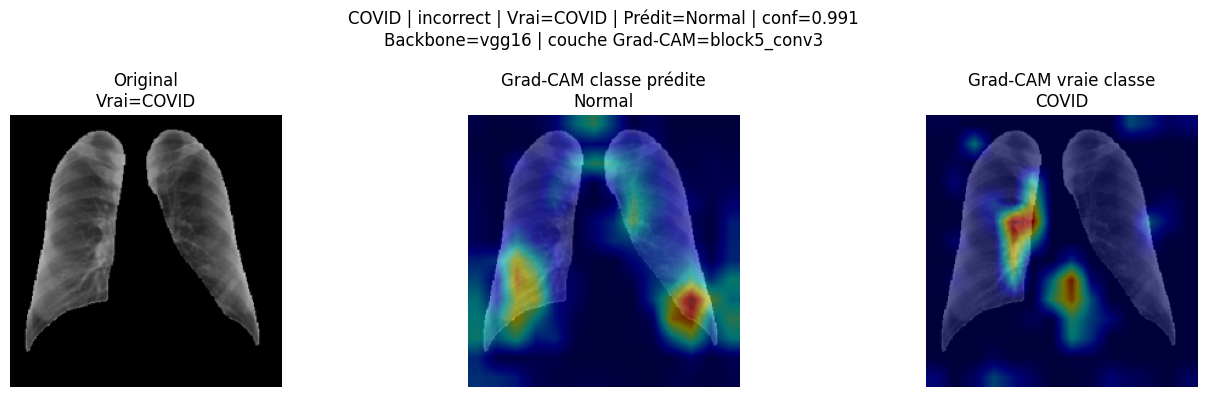

##########################################################################################
Grad-CAM — catégorie : Normal
##########################################################################################


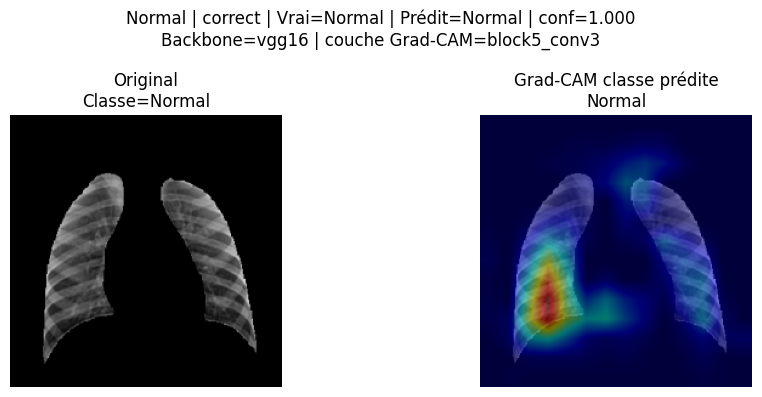

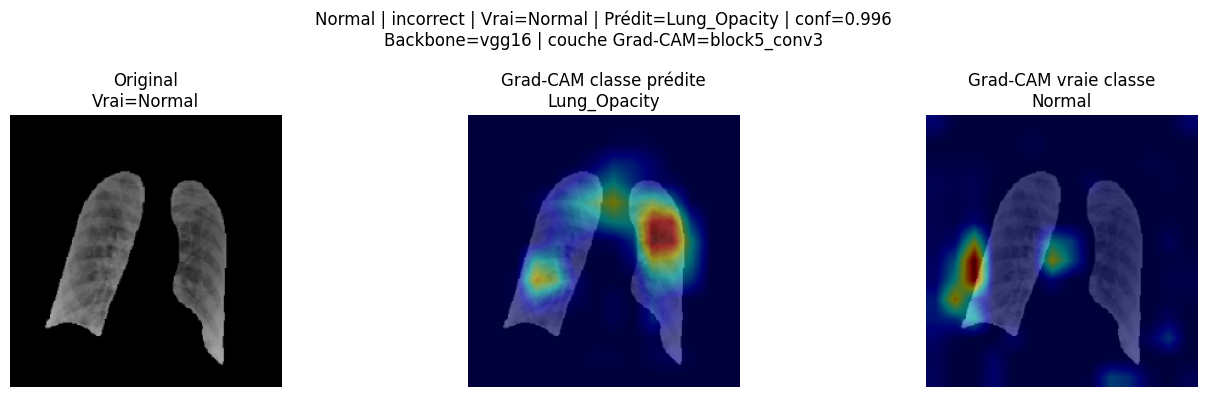

##########################################################################################
Grad-CAM — catégorie : Lung_Opacity
##########################################################################################


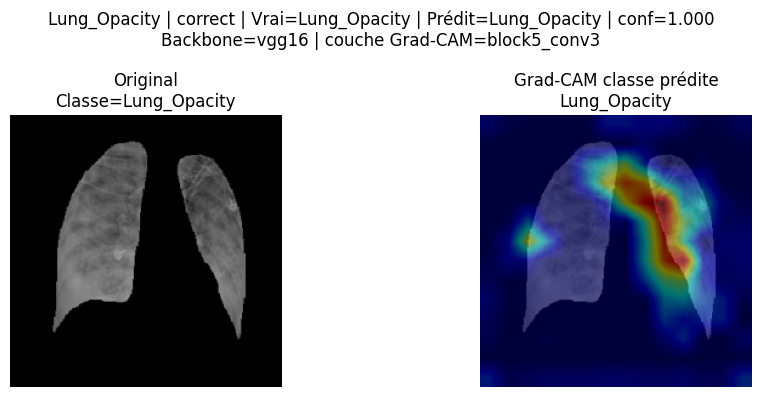

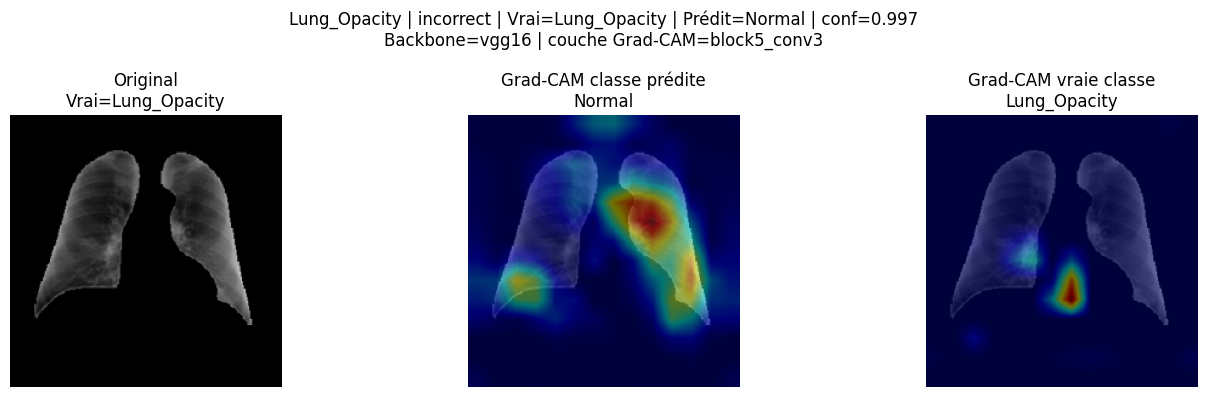

##########################################################################################
Grad-CAM — catégorie : Viral Pneumonia
##########################################################################################


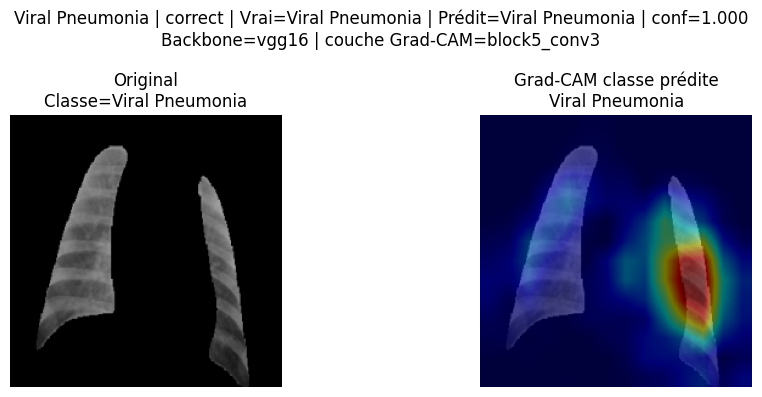

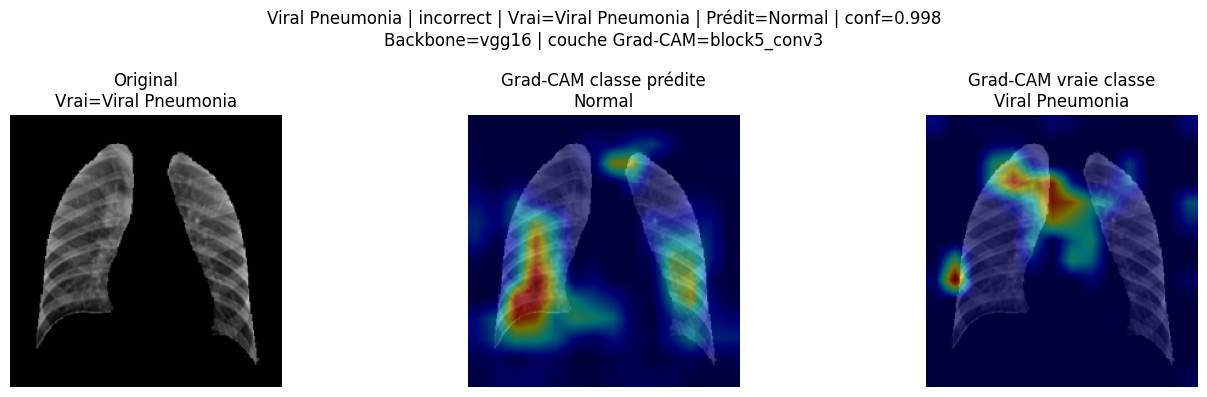

In [27]:

# =========================
# Affichage Grad-CAM pour les exemples sélectionnés
# =========================

def show_gradcam_for_row(row, model, backbone_name, target_layer_name):
    image_np = load_preprocessed_image_from_row(row)
    batch = np.expand_dims(image_np, axis=0).astype(np.float32)

    true_id = int(row["y_true"])
    pred_id = int(row["y_pred"])

    pred_heatmap = make_gradcam_heatmap(
        batch, model, backbone_name=backbone_name, target_layer_name=target_layer_name, class_index=pred_id
    )
    pred_overlay = overlay_gradcam_on_image(image_np, pred_heatmap)

    if true_id != pred_id:
        true_heatmap = make_gradcam_heatmap(
            batch, model, backbone_name=backbone_name, target_layer_name=target_layer_name, class_index=true_id
        )
        true_overlay = overlay_gradcam_on_image(image_np, true_heatmap)

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow((image_np / 255.0).clip(0, 1))
        axes[0].set_title(f"Original\nVrai={ID_TO_CLASS[true_id]}")
        axes[0].axis("off")

        axes[1].imshow(pred_overlay)
        axes[1].set_title(f"Grad-CAM classe prédite\n{ID_TO_CLASS[pred_id]}")
        axes[1].axis("off")

        axes[2].imshow(true_overlay)
        axes[2].set_title(f"Grad-CAM vraie classe\n{ID_TO_CLASS[true_id]}")
        axes[2].axis("off")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow((image_np / 255.0).clip(0, 1))
        axes[0].set_title(f"Original\nClasse={ID_TO_CLASS[true_id]}")
        axes[0].axis("off")

        axes[1].imshow(pred_overlay)
        axes[1].set_title(f"Grad-CAM classe prédite\n{ID_TO_CLASS[pred_id]}")
        axes[1].axis("off")

    plt.suptitle(
        f"{row['true_name']} | {row['example_type']} | "
        f"Vrai={row['true_name']} | Prédit={row['pred_name']} | conf={row['pred_confidence']:.3f}\n"
        f"Backbone={backbone_name} | couche Grad-CAM={target_layer_name}"
    )
    plt.tight_layout()
    plt.show()

for category in CATEGORIES:
    cat_subset = examples_df[examples_df["true_name"] == category]

    if len(cat_subset) == 0:
        print(f"Aucun exemple sélectionné pour {category}.")
        continue

    print("#" * 90)
    print(f"Grad-CAM — catégorie : {category}")
    print("#" * 90)

    for _, row in cat_subset.iterrows():
        show_gradcam_for_row(row, model, gradcam_backbone_name, gradcam_layer_name)


In [31]:
# =========================
# Nettoyage mémoire (optionnel)
# =========================

gc.collect()


30018